# SPY 500 Analysis

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [61]:
#ticker
ticker_symbol = "VOO"

In [62]:
#Get data from yahoo finance api
ticker = yf.Ticker(ticker_symbol)
data = ticker.history(period="max")

print(data)

                                 Open        High         Low       Close  \
Date                                                                        
2010-09-09 00:00:00-04:00   77.890943   77.890943   76.857463   76.994247   
2010-09-10 00:00:00-04:00   77.267783   77.404567   76.979019   77.343773   
2010-09-13 00:00:00-04:00   78.240500   78.377284   77.890942   78.316490   
2010-09-14 00:00:00-04:00   78.149269   78.635617   77.799710   78.301254   
2010-09-15 00:00:00-04:00   77.982116   78.559644   77.814934   78.498856   
...                               ...         ...         ...         ...   
2025-10-16 00:00:00-04:00  613.109985  614.799988  604.140015  607.390015   
2025-10-17 00:00:00-04:00  606.340027  612.020020  605.099976  610.760010   
2025-10-20 00:00:00-04:00  613.510010  618.010010  613.510010  617.169983   
2025-10-21 00:00:00-04:00  617.330017  618.739990  615.979980  617.090027   
2025-10-22 00:00:00-04:00  617.830017  617.830017  609.830017  613.969971   

In [63]:
#Predicting whether the stock price will go up or down in 90 days
data["90Days"]=data["Close"].shift(-90)

#Create target variable
data["Target"]=(data["90Days"]>data["Close"]).astype(int)


data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,90Days,Target
Date,,,,,,,,,,
2010-09-09 00:00:00-04:00,77.890943,77.890943,76.857463,76.994247,26500,0.0,0.0,0.0,90.953087,1
2010-09-10 00:00:00-04:00,77.267783,77.404567,76.979019,77.343773,8600,0.0,0.0,0.0,90.047363,1
2010-09-13 00:00:00-04:00,78.240500,78.377284,77.890942,78.316490,33750,0.0,0.0,0.0,89.939926,1
2010-09-14 00:00:00-04:00,78.149269,78.635617,77.799710,78.301254,59400,0.0,0.0,0.0,90.139496,1
2010-09-15 00:00:00-04:00,77.982116,78.559644,77.814934,78.498856,9250,0.0,0.0,0.0,90.692101,1


# Exploratory Data Analysis

In [64]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,90Days,Target
count,3804.000000,3804.000000,3804.000000,3804.000000,3.804000e+03,3804.000000,3804.000000,3804.0,3714.000000,3804.000000
mean,250.019344,251.308681,248.593807,250.057720,3.008224e+06,0.018311,0.000131,0.0,254.082724,0.772082
std,137.054357,137.769867,136.257701,137.079422,2.889683e+06,0.152077,0.008107,0.0,136.238787,0.419545
min,77.237393,77.404567,76.536225,76.994247,8.600000e+03,0.000000,0.000000,0.0,78.172279,0.000000
25%,144.729498,145.771114,144.010852,144.868259,1.117350e+06,0.000000,0.000000,0.0,148.918568,1.000000
50%,216.683777,217.608447,214.928569,216.509178,2.417675e+06,0.000000,0.000000,0.0,219.816277,1.000000
75%,356.453065,358.859300,354.273328,357.634422,4.107550e+06,0.000000,0.000000,0.0,359.344101,1.000000
max,619.229980,619.599976,615.979980,618.770020,3.541800e+07,1.812000,0.500000,0.0,618.770020,1.000000


The stock ranged from 76.99 to 618.77.

The target is slightly imbalanced with more 90 days returns being positive than negative or zero.

The average dividend was 0.01 with the highest being 1.81.

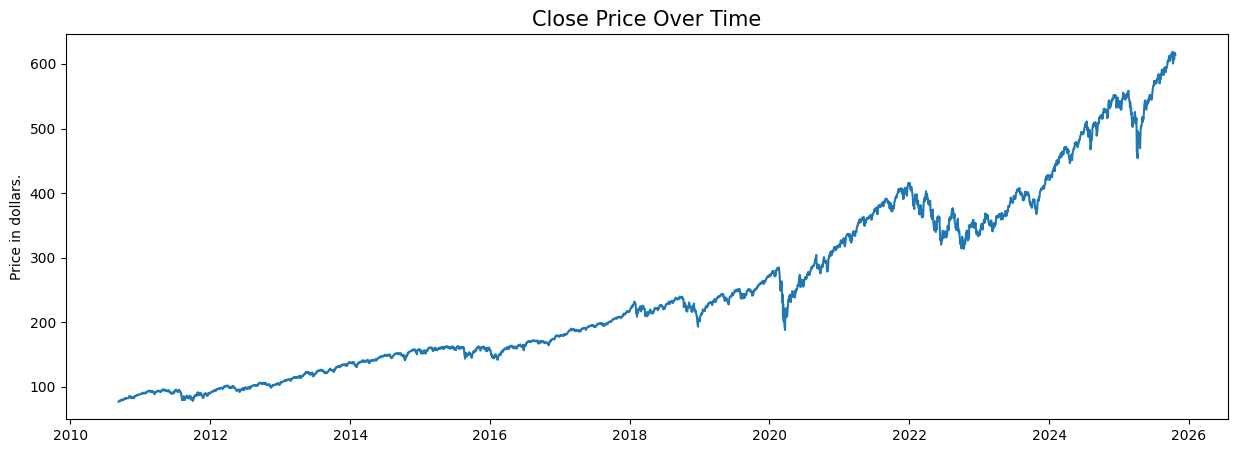

In [65]:
plt.figure(figsize=(15,5))
plt.plot(data['Close'])
plt.title('Close Price Over Time', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

The stock has gone up overtime nearly consistently on a large scale.  There are some pull backs.  The goal is to see if the various machine learning models can determine when there will be a pullback over the next 90 days and when the stock will go up over the next 90 days.


# Machine Learning

In [66]:
#Define features for ML and Target Variables
features = data[["Open", "High", "Low", "Close", "Volume"]]
target = data['Target']

features_scaled = StandardScaler().fit_transform(features)

In [67]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)

# Check the shapes of the resulting datasets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3043, 5)
Testing set shape: (761, 5)


In [68]:
#Create Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [69]:
#Model make predictions
predict = model.predict(X_test)

In [70]:
#Evaluate the results of the model
accuracy = accuracy_score(y_test, predict)
print("Accuracy:", accuracy)
classification = classification_report(y_test, predict)
print("Classification Report:")
print(classification)
confusion = confusion_matrix(y_test, predict)
print("Confusion Matrix:")
print(confusion)

Accuracy: 0.8672798948751642
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.65      0.69       170
           1       0.90      0.93      0.92       591

    accuracy                           0.87       761
   macro avg       0.82      0.79      0.80       761
weighted avg       0.86      0.87      0.86       761

Confusion Matrix:
[[110  60]
 [ 41 550]]


The model had an overall accuracy of 87%.

The model did not do well with predicting when the VOO would go down over the next 90 days.

In [71]:
#Test Logistic Regression Model
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [72]:
#Make predictions
predict2 = model2.predict(X_test)

In [73]:
#Evaluate the results of the model
accuracy = accuracy_score(y_test, predict2)
print("Accuracy:", accuracy)
classification = classification_report(y_test, predict2)
print("Classification Report:")
print(classification)
confusion = confusion_matrix(y_test, predict2)
print("Confusion Matrix:")
print(confusion)

Accuracy: 0.7766097240473062
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       170
           1       0.78      1.00      0.87       591

    accuracy                           0.78       761
   macro avg       0.39      0.50      0.44       761
weighted avg       0.60      0.78      0.68       761

Confusion Matrix:
[[  0 170]
 [  0 591]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The logistic regression model did not accurately determine when VOO would go down over the next 90 days and had a 0%.

In [74]:
#Create SVM Model
model3 = SVC(kernel='rbf')
model3.fit(X_train, y_train)

SVC()

In [75]:
#Make predictions
predict3 = model3.predict(X_test)

In [76]:
#Evaluate the results of the model
accuracy = accuracy_score(y_test, predict3)
print("Accuracy:", accuracy)
classification = classification_report(y_test, predict3)
print("Classification Report:")
print(classification)
confusion = confusion_matrix(y_test, predict3)
print("Confusion Matrix:")
print(confusion)

Accuracy: 0.8055190538764783
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.17      0.28       170
           1       0.81      0.99      0.89       591

    accuracy                           0.81       761
   macro avg       0.81      0.58      0.58       761
weighted avg       0.81      0.81      0.75       761

Confusion Matrix:
[[ 29 141]
 [  7 584]]


The SVM failed to detect a reasonable percentage when the VOO would go down over the next 90 days.

In [77]:
#XGBoost
model4 = XGBClassifier(n_estimators = 100, random_state = 42)
model4.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [78]:
predict4 = model4.predict(X_test)

In [79]:
#Evaluate the results of the model
accuracy = accuracy_score(y_test, predict4)
print("Accuracy:", accuracy)
classification = classification_report(y_test, predict4)
print("Classification Report:")
print(classification)
confusion = confusion_matrix(y_test, predict4)
print("Confusion Matrix:")
print(confusion)

Accuracy: 0.8646517739816032
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.62      0.67       170
           1       0.90      0.93      0.91       591

    accuracy                           0.86       761
   macro avg       0.81      0.78      0.79       761
weighted avg       0.86      0.86      0.86       761

Confusion Matrix:
[[106  64]
 [ 39 552]]


The Random Forest Models and XGBoost Models were the best at predicting if the VOO would go down or up over the next 90 days.  To enhance the analysis, adjusting the models parameters would help fine tune the models to determine which one would be best.